In [1]:
import pandas as pd

cdr1+2+3+frames
перевести подсчет расстояний на си
1. сделать 1 картинку: какие бывают кейсы и степы пайплайна (просто графический абстракт) + учесть типы бэкграунда
- cmv+ebv -- поиск клеточной памяти (воспроизведение статьи) -- tutorial textbook case
- бехтерева (много положительных и много контролей, редкий мотив), находится на уровне популяции но не факт что в каждом отдельно, маленький по экспансии
- yfv (парные сэмплы, можем найти мотивы которые в динамике вырастают), можем посмотрет ьи пцбличные и индивидуальный иммунный ответ
- 
2. найти мотивы которые встречаются у CMV+HLA-specific -- матрица для каждого мотива, как выглядит матрица типа cmv-hla 
3. покзаать что аллель+cmv специфичные будут большие по экспансии
4. взять из vdjdb все ebv-специфичные -> мотивы ->  показать что для разных аллелей вылезают разные мотивы -> если в пациенте нашелся моттв говорим что он имеет эту HLA, показать что если брать из vdjdb все то мусор а если мотивные то ок

для вакцинации:
точка до -- не глубоко прочитано, не наберется норм покрытия
взять юэкграунд наивными
например в фмба -- -просто беерм все мотивы и дальше статистикой смотрим что изменилось
H0 - до и после по ридам в кластере одинаково

In [2]:
import sys
sys.path.append('/home/evlasova/mirpy')

In [3]:
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

In [4]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/emerson/tcrempnet'
    summary = pd.read_csv(f'{data_path}/{sample_name}_summary_tcrempnet.tsv', sep='\t')
    # summary = summary[summary.cluster_size > 4]
    c0 = 857708
    c15 = len(pd.read_csv(
        f'/projects/immunestatus/emerson/airr_format/{sample_name}.tsv', sep='\t'))
    print(f'''
    sample: {sample_name}
    clusters: {len(summary)}
    overall from background: {c0}
    overall from sample: {c15}
    ''')
    return summary, c0, c15

In [5]:
vdjdb = pd.read_csv('vdjdb.slim.txt', sep='\t')
vdjdb = vdjdb[(vdjdb['vdjdb.score'] == 3) & (
    vdjdb['vdjdb.pgen.score'] > 1) & (
    vdjdb['antigen.epitope'] == 'NLVPMVATV') & (
    vdjdb['gene'] == 'TRB')].reset_index(drop=True)
vdjdb

,gene,cdr3,species,antigen.epitope,antigen.gene,antigen.species,complex.id,v.segm,j.segm,mhc.a,mhc.b,mhc.class,reference.id,vdjdb.score,vdjdb.pgen.score,j.start,v.end
0,TRB,CAAGTRTDTQYF,HomoSapiens,NLVPMVATV,pp65,CMV,"10317,10448",TRBV2*01,TRBJ2-3*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,6,2
1,TRB,CAIDRVGTGELFF,HomoSapiens,NLVPMVATV,pp65,CMV,"10377,10508",TRBV30*01,TRBJ2-2*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,7,2
2,TRB,CAISEQEDQPQHF,HomoSapiens,NLVPMVATV,pp65,CMV,"10326,10457",TRBV10-3*01,TRBJ1-5*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,8,5
3,TRB,CAISESRSRVTDTQYF,HomoSapiens,NLVPMVATV,pp65,CMV,"10333,10464",TRBV10-3*01,TRBJ2-3*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,10,5
4,TRB,CAISVSGTRVYNEQFF,HomoSapiens,NLVPMVATV,pp65,CMV,"10362,10493",TRBV10-3*01,TRBJ2-1*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,TRB,CSGGQDYNEQFF,HomoSapiens,NLVPMVATV,pp65,CMV,"10279,10410",TRBV29-1*01,TRBJ2-1*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,6,2
187,TRB,CSVDPGHTGEKLFF,HomoSapiens,NLVPMVATV,pp65,CMV,"10266,10397,10532",TRBV29-1*01,TRBJ1-4*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,9,3
188,TRB,CSVEEGSRAQYF,HomoSapiens,NLVPMVATV,pp65,CMV,10587,TRBV29-1*01,TRBJ2-5*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,9,4
189,TRB,CSVEGDTGELFF,HomoSapiens,NLVPMVATV,pp65,CMV,"10367,10498",TRBV29-1*01,TRBJ2-2*01,HLA-A*02:01,B2M,MHCI,https://doi.org/10.1101/2020.05.04.20085779,3,2,6,4


In [6]:
as_seqs = vdjdb.cdr3
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]

In [7]:
as_clonotypes = [ClonotypeAA(cdr3aa=x) for x in as_seqs]
vdjdb = ClonotypeDataset(as_clonotypes)

In [8]:
vdjdb

A dataset of 191 clonotypes and 185 clusters

In [9]:
vdjdb.get_matching_clonotypes('CASSLAPGATNEQLFF')

set()

In [10]:
def get_clonotypes(sample_name):
    data_path = f'/projects/immunestatus/emerson/tcrempnet'
    df = pd.read_csv(f'{data_path}/{sample_name}_enriched_clonotypes_tcremp.tsv', sep='\t')
    return df

In [11]:
def has_vdjdb_match(x, threshold=1):
    return len(vdjdb.get_matching_clonotypes(x, threshold=threshold))

def get_cluster_matches_vdjdb(df, cluster_id):
    df = df[df.cluster_id == cluster_id]
    matches = df.cdr3aa_beta.apply(has_vdjdb_match)
    return sum(matches) > 0

In [12]:
samples = """HIP00594  HIP00777  HIP03370  HIP03511  HIP03720  
HIP04509  HIP05559  HIP05815  HIP05960  HIP08653  
HIP08986  HIP09020  HIP10716  HIP11937  HIP12900  
HIP13513  HIP13903  HIP13967  HIP13986  HIP13994  
HIP14041  HIP14051  HIP14157  HIP14194  HIP14227  
HIP15854""".split()

In [13]:
sample_to_data = {}

for sample in samples:
    try:
        info = get_sample_info(sample)
        df = get_clonotypes(sample)
        info[0]['vdjdb'] = info[0].cluster_id.apply(lambda x: get_cluster_matches_vdjdb(df, x))
        sample_to_data[sample] = info
    except Exception as e:
        print(f'Problem with {sample}')


    sample: HIP00594
    clusters: 27801
    overall from background: 857708
    overall from sample: 155820
    

    sample: HIP00777
    clusters: 30688
    overall from background: 857708
    overall from sample: 254385
    

    sample: HIP03370
    clusters: 31501
    overall from background: 857708
    overall from sample: 293545
    

    sample: HIP03511
    clusters: 29035
    overall from background: 857708
    overall from sample: 202864
    
Problem with HIP03720

    sample: HIP04509
    clusters: 27420
    overall from background: 857708
    overall from sample: 142950
    

    sample: HIP05559
    clusters: 30734
    overall from background: 857708
    overall from sample: 267339
    

    sample: HIP05815
    clusters: 24386
    overall from background: 857708
    overall from sample: 29639
    

    sample: HIP05960
    clusters: 30094
    overall from background: 857708
    overall from sample: 245259
    

    sample: HIP08653
    clusters: 30756
    overall from 

In [14]:
samples = list(sample_to_data.keys())

In [15]:
len(samples)

20

In [16]:
import seaborn as sns

In [17]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df, pval_threshold=0.05, fold_threshold=0, sample_name="", ax=None):
    df = df.copy()
    df['log10_pval'] = -np.log10(df['enrichment_pvalue_zbinom'] + 1e-10)
    df['significant'] = (df['enrichment_fdr_zbinom'] < pval_threshold) & (df['log_fold_change'] > fold_threshold)

    # Определение цветов
    main_color = '#2171b5'   # синий для значимых
    base_color = '#ffffcc'   # жёлтый для остальных

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Рисуем все точки (не vdjdb)
    sns.scatterplot(
        data=df[~df['vdjdb']],
        x='log_fold_change',
        y='log10_pval',
        hue='significant',
        palette={True: main_color, False: base_color},
        edgecolor='black',
        linewidth=0.3,
        ax=ax,
        # s=70,
        alpha=0.85,
    )

    # Поверх них рисуем vdjdb точки красными квадратами
    sns.scatterplot(
        data=df[df['vdjdb']],
        x='log_fold_change',
        y='log10_pval',
        marker='s',
        color='red',
        edgecolor='black',
        linewidth=0.4,
        ax=ax,
        # s=70,
        alpha=1.0,
        label='vdjdb cmv'
    )

    # Линии порогов
    bonferroni_thresh = max(df[df['enrichment_fdr_zbinom'] < pval_threshold]['enrichment_pvalue_zbinom'], default=1.0)
    log10_bonferroni = -np.log10(bonferroni_thresh)
    ax.axvline(fold_threshold, ls='--', color='black')
    ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
    ax.axhline(log10_bonferroni, ls=':', color='blue')

    # Подписи
    num_significant = df['significant'].sum()
    ax.set_xlabel('log2(Fold Enrichment)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{sample_name}: # clusters (fdr < {pval_threshold}): {num_significant}')
    ax.legend()


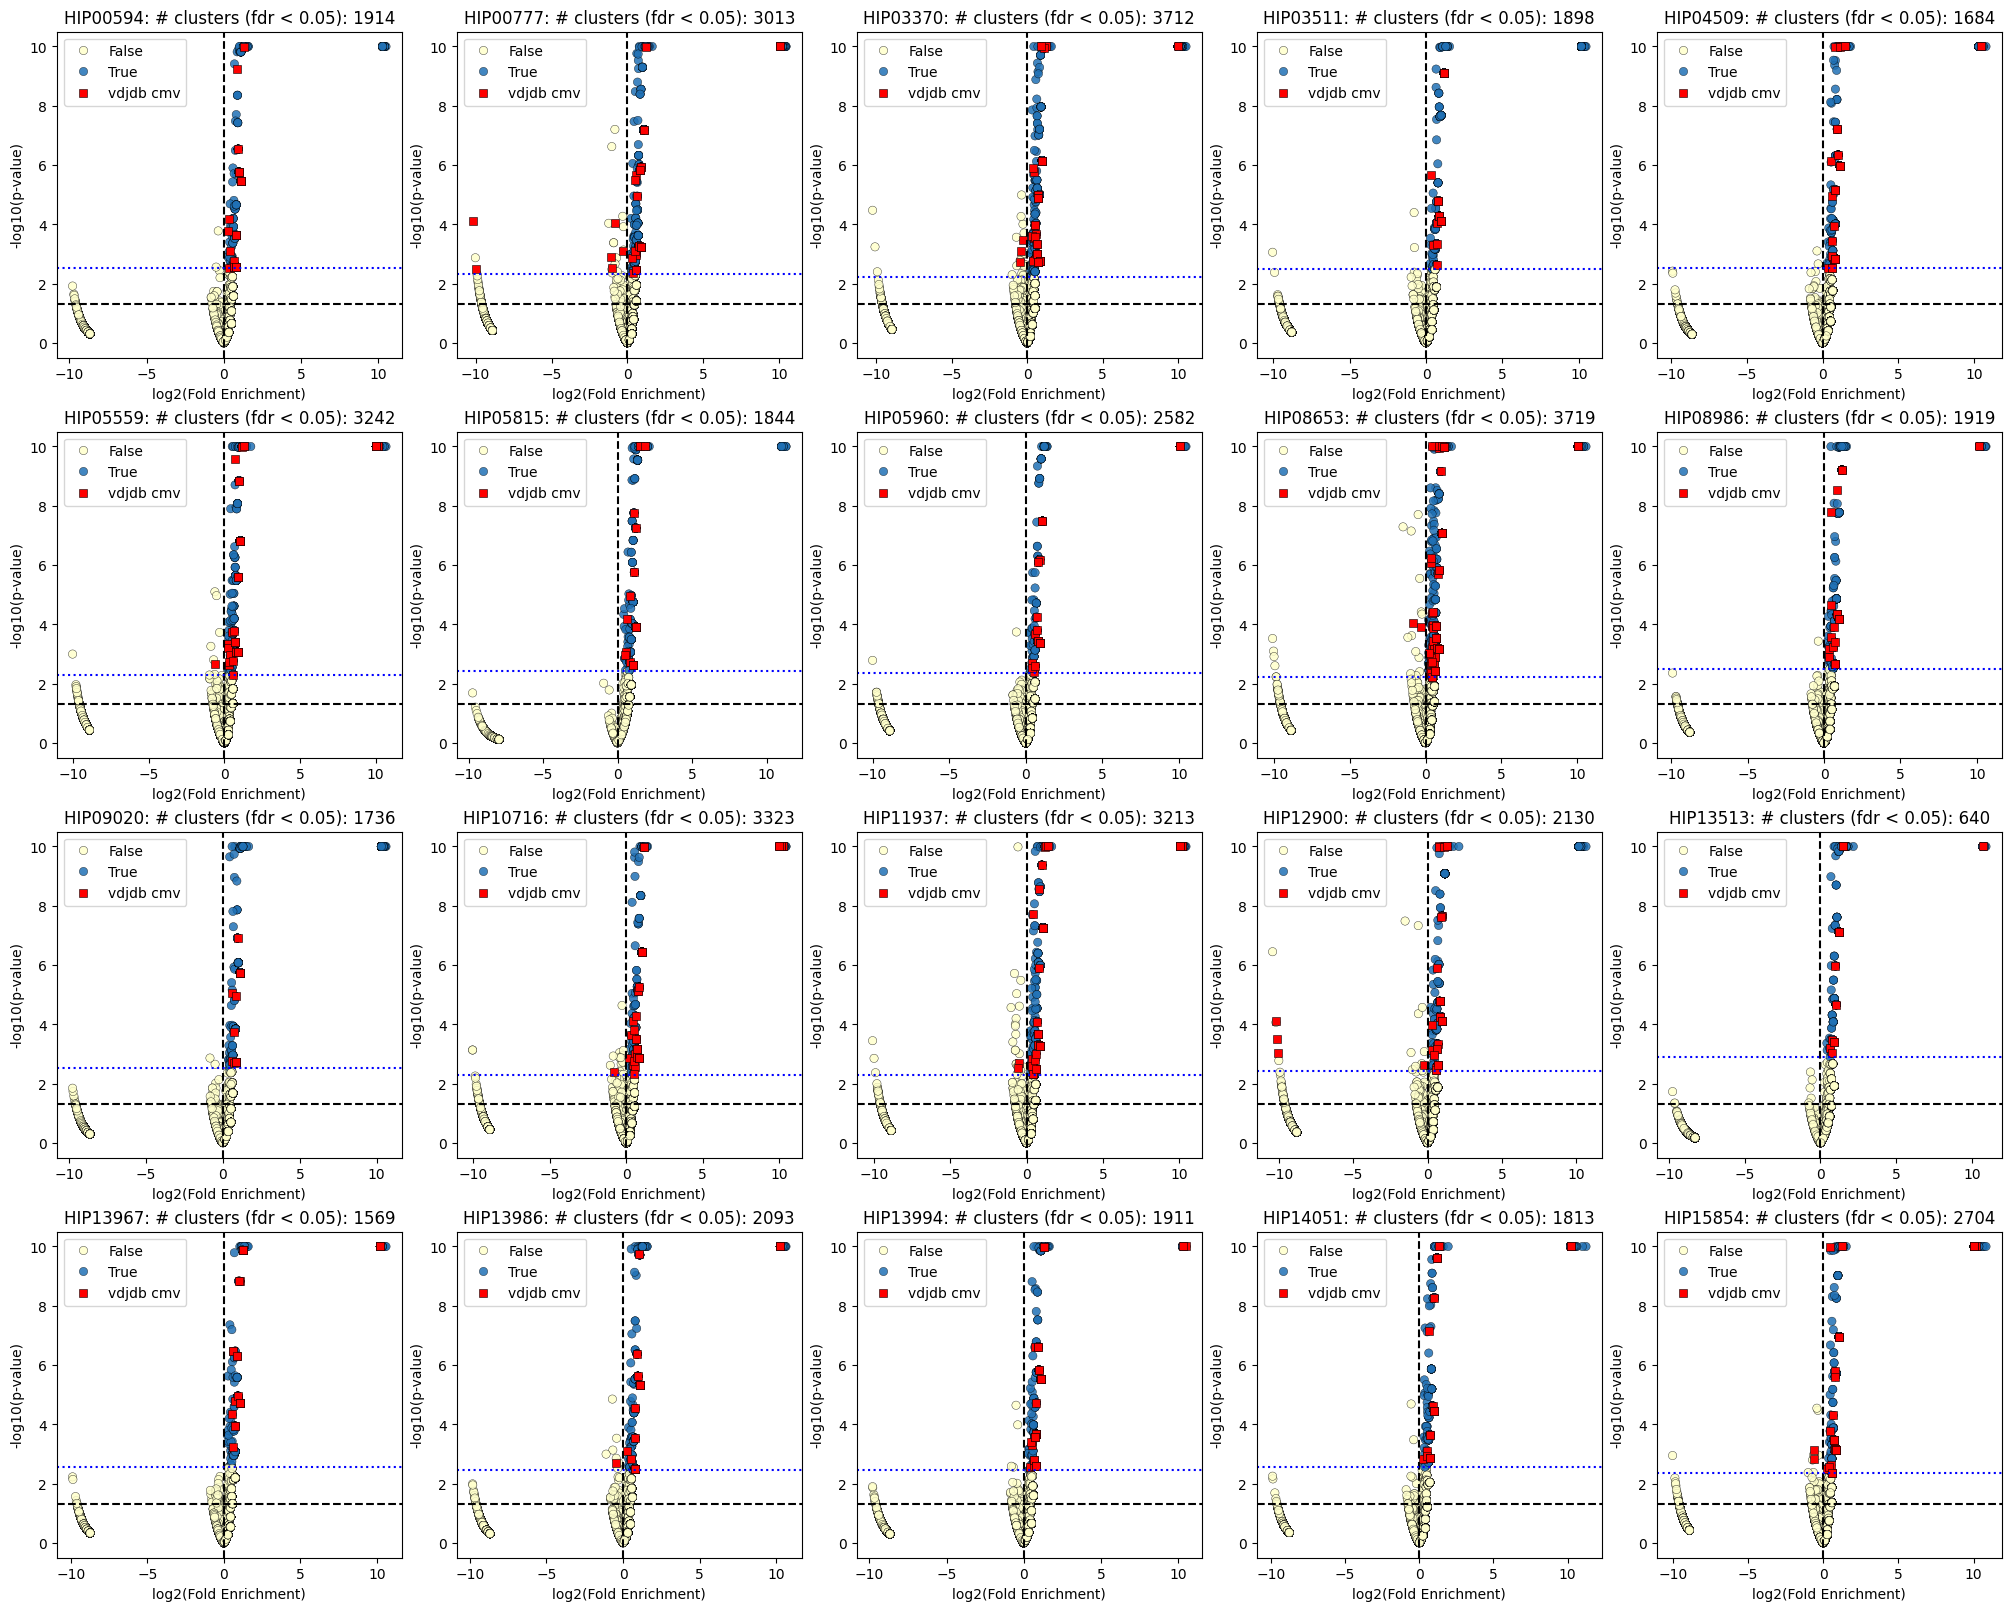

In [18]:
import matplotlib.pyplot as plt

ncols = 5
nrows = 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4), constrained_layout=True)

for i, s in enumerate(samples):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    s_res = sample_to_data[s]
    plot_volcano(s_res[0], ax=ax, fold_threshold=0, sample_name=s)

# Удалим лишние пустые сабплоты (если samples < 27)
for j in range(len(samples), ncols * nrows):
    fig.delaxes(axes[j // ncols, j % ncols])
plt.savefig('as_volcanos.png', dpi=300)
plt.show()

In [19]:
all_info = []
for s in samples:
    s_res = sample_to_data[s][0]
    res_df = s_res[['cluster_id', 'vdjdb', 'enrichment_fdr_zbinom', 'log_fold_change']]
    res_df = res_df[(res_df.enrichment_fdr_zbinom < 0.05) & (res_df.log_fold_change > 0)]
    res_df['sample'] = s
    all_info.append(res_df)

In [20]:
joint = pd.concat(all_info)

In [21]:
joint

,cluster_id,vdjdb,enrichment_fdr_zbinom,log_fold_change,sample
0,0,False,0.000082,1.103537,HIP00594
2,2,False,0.041238,0.677568,HIP00594
10,10,False,0.000000,10.404567,HIP00594
12,12,False,0.000000,10.279628,HIP00594
13,13,False,0.040628,0.802507,HIP00594
...,...,...,...,...,...
30181,30181,False,0.008777,0.877211,HIP15854
30203,30203,False,0.008777,0.877211,HIP15854
30210,30210,False,0.008777,0.877211,HIP15854
30211,30211,False,0.008777,0.877211,HIP15854


In [22]:
joint = joint.rename(columns={'log_fold_change': 'fold_enrichment', 'enrichment_fdr_zbinom': 'pvalue'})

In [23]:
joint[joint.vdjdb].sort_values(by='sample')

,cluster_id,vdjdb,pvalue,fold_enrichment,sample
191,191,True,5.517002e-08,0.869454,HIP00594
3694,3694,True,4.062779e-02,0.802507,HIP00594
3816,3816,True,8.225495e-05,1.103537,HIP00594
4755,4755,True,3.530495e-02,0.626416,HIP00594
4979,4979,True,5.142988e-03,0.802507,HIP00594
...,...,...,...,...,...
4867,4867,True,5.092682e-06,1.053302,HIP15854
4910,4910,True,8.777188e-03,0.877211,HIP15854
4959,4959,True,8.777188e-03,0.752272,HIP15854
2607,2607,True,1.313644e-10,0.456571,HIP15854


In [24]:
all_clonotypes_enriched = []
for patient in samples:
    t = get_clonotypes(patient).drop(columns=['enrichment_pvalue_zbinom'])
    # t = t[t.source == 'sample']
    t = t[t.cluster_id.isin(joint[joint['sample'] == patient].cluster_id)]
    t['cluster_id'] = patient + '_c' + t.cluster_id.astype(str)
    t['sample_name'] = patient
    all_clonotypes_enriched.append(t)

In [25]:
data = pd.concat(all_clonotypes_enriched)#.drop(columns=['source'])
data

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name
0,s_26,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594
1,s_330,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594
2,b_66787,HIP00594_c0,CASRGTGPYEQYF,TRBV6-1*01,TRBJ2-7*01,background,HIP00594
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594
...,...,...,...,...,...,...,...
12020,s_259988,HIP15854_c15112,CASSLALEGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854
12021,s_259993,HIP15854_c15112,CASSLALQGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854
12022,s_260763,HIP15854_c15128,RASSLSSGGRAYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854
12023,s_260909,HIP15854_c15128,CASSLSSGGRSYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854


In [26]:
data['vdjdb'] = data.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [27]:
data[data.vdjdb][['sample_name']].drop_duplicates()

,sample_name
382,HIP00594
834,HIP00777
98,HIP03370
324,HIP03511
81,HIP04509
286,HIP05559
531,HIP05815
23,HIP05960
142,HIP08653
463,HIP08986


In [28]:
found_clonotypes = [ClonotypeAA(cdr3aa=x) for x in data.cdr3aa_beta]
dataset = ClonotypeDataset(found_clonotypes)

In [29]:
import networkx as nx
from collections import defaultdict

In [30]:
df = data

In [31]:
# 1. Построить отображение: cdr3aa → множество cluster_id
cdr3_to_clusters = defaultdict(set)
for _, row in df.iterrows():
    cdr3_to_clusters[row['cdr3aa_beta']].add(row['cluster_id'])

# 2. Построить граф кластеров, связанных общими сиквенсами
G = nx.Graph()
G.add_nodes_from(df['cluster_id'].unique())

for clusters in cdr3_to_clusters.values():
    clusters = list(clusters)
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            G.add_edge(clusters[i], clusters[j])

# 3. Компоненты связности → объединённые кластеры
cluster_mapping = {}
for new_id, component in enumerate(nx.connected_components(G)):
    for cluster_id in component:
        cluster_mapping[cluster_id] = new_id

# 4. Применить маппинг
df['merged_cluster_id'] = df['cluster_id'].map(cluster_mapping)

In [32]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id
0,s_26,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594,False,0
1,s_330,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594,False,0
2,b_66787,HIP00594_c0,CASRGTGPYEQYF,TRBV6-1*01,TRBJ2-7*01,background,HIP00594,False,0
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,1
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,1
...,...,...,...,...,...,...,...,...,...
12020,s_259988,HIP15854_c15112,CASSLALEGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854,False,25547
12021,s_259993,HIP15854_c15112,CASSLALQGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854,False,25547
12022,s_260763,HIP15854_c15128,RASSLSSGGRAYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854,False,25548
12023,s_260909,HIP15854_c15128,CASSLSSGGRSYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854,False,25548


In [33]:
df.source.value_counts()

source
sample        132868
background     92148
Name: count, dtype: int64

In [34]:
df['as_pattern'] = df.cdr3aa_beta.apply(lambda x: has_vdjdb_match(x) > 0)

In [35]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern
0,s_26,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594,False,0,False
1,s_330,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594,False,0,False
2,b_66787,HIP00594_c0,CASRGTGPYEQYF,TRBV6-1*01,TRBJ2-7*01,background,HIP00594,False,0,False
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,1,False
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,1,False
...,...,...,...,...,...,...,...,...,...,...
12020,s_259988,HIP15854_c15112,CASSLALEGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854,False,25547,False
12021,s_259993,HIP15854_c15112,CASSLALQGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854,False,25547,False
12022,s_260763,HIP15854_c15128,RASSLSSGGRAYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854,False,25548,False
12023,s_260909,HIP15854_c15128,CASSLSSGGRSYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854,False,25548,False


In [36]:
df.cluster_id.value_counts()

cluster_id
HIP08653_c131      301
HIP12900_c337      263
HIP00777_c374      246
HIP08653_c747      243
HIP05815_c7        236
                  ... 
HIP00594_c79         3
HIP00594_c80         3
HIP15854_c14224      3
HIP15854_c14278      3
HIP15854_c14299      3
Name: count, Length: 46659, dtype: int64

In [37]:
df.merged_cluster_id.value_counts()

merged_cluster_id
8      4709
132    2997
84     2623
510    2609
209    1921
       ... 
17        3
20        3
26        3
29        3
30        3
Name: count, Length: 25549, dtype: int64

In [38]:
df.groupby("merged_cluster_id").nunique()[["sample_name", 'as_pattern']]
# test['as_pattern'].value_counts()

,sample_name,as_pattern
merged_cluster_id,,
0,1,1
1,4,1
2,1,1
3,1,1
4,4,1
...,...,...
25544,1,1
25545,1,1
25546,1,1


In [39]:
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()
source_counts

source,merged_cluster_id,background,sample
0,0,1,2
1,1,16,13
2,2,0,4
3,3,0,3
4,4,13,18
...,...,...,...
25544,25544,1,2
25545,25545,1,2
25546,25546,1,2
25547,25547,0,3


In [40]:
df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',          # количество уникальных значений
    'as_pattern': 'any'               # хотя бы одно True
})

,sample_name,as_pattern
merged_cluster_id,,
0,1,False
1,4,False
2,1,False
3,1,False
4,4,False
...,...,...
25544,1,False
25545,1,False
25546,1,False


In [41]:
from mir.basic.pgen import OlgaModel

In [42]:
olga = OlgaModel()

In [43]:
olga.compute_pgen_cdr3aa('CASSPPSGSYEQYF')

2.0855611266511384e-07

In [44]:
df

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,sample_name,vdjdb,merged_cluster_id,as_pattern
0,s_26,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594,False,0,False
1,s_330,HIP00594_c0,CASRGKGPYEQYF,TRBV6-1*01,TRBJ2-7*01,sample,HIP00594,False,0,False
2,b_66787,HIP00594_c0,CASRGTGPYEQYF,TRBV6-1*01,TRBJ2-7*01,background,HIP00594,False,0,False
3,s_41,HIP00594_c2,CASSEGTGGTDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,1,False
4,s_42248,HIP00594_c2,CASSDGAGGRDTQYF,TRBV6-4*01,TRBJ2-3*01,sample,HIP00594,False,1,False
...,...,...,...,...,...,...,...,...,...,...
12020,s_259988,HIP15854_c15112,CASSLALEGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854,False,25547,False
12021,s_259993,HIP15854_c15112,CASSLALQGNEQYF,TRBV5-1*01,TRBJ2-7*01,sample,HIP15854,False,25547,False
12022,s_260763,HIP15854_c15128,RASSLSSGGRAYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854,False,25548,False
12023,s_260909,HIP15854_c15128,CASSLSSGGRSYEQYF,TRBV27*01,TRBJ2-7*01,sample,HIP15854,False,25548,False


In [ ]:
df['pgen'] = df.cdr3aa_beta.apply(olga.compute_pgen_cdr3aa)

In [ ]:
df

In [ ]:
# Считаем общий размер кластера
cluster_sizes = df.groupby("merged_cluster_id").size().reset_index(name="cluster_size")

# Считаем количество пациентов и наличие паттерна
n_patients = df.groupby('merged_cluster_id').agg({
    'sample_name': 'nunique',
    'as_pattern': 'any', 
    'pgen': 'mean'
}).reset_index().rename(columns={'sample_name': "n_patients"})

# Считаем количество элементов из каждого источника (source)
source_counts = df.pivot_table(index='merged_cluster_id', columns='source', 
                               values='clone_id', aggfunc='count', fill_value=0).reset_index()

# Объединяем таблицы
summary = cluster_sizes.merge(n_patients, on="merged_cluster_id")
summary = summary.merge(source_counts, on="merged_cluster_id")

# Считаем доли элементов из каждого источника
summary['sample_fraction'] = summary.get('sample', 0) / summary['cluster_size']
summary['background_fraction'] = summary.get('background', 0) / summary['cluster_size']

# Сортировка
summary = summary.sort_values(by=["n_patients", "cluster_size"], ascending=False)


In [ ]:
summary

In [ ]:
#summary[summary.n_patients > 3].sort_values(by=['pgen',  'sample_fraction', 'n_patients'], ascending=True).head(50).reset_index(drop=True)

In [ ]:
summary.sort_values(by='cluster_size', ascending=False).head(10)

In [ ]:
summary[summary.as_pattern]

In [ ]:
import logomaker

In [ ]:
def plot_logo(clonotypes):
    mat_df = logomaker.alignment_to_matrix(clonotypes)
    logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)

In [ ]:
mat_df = logomaker.alignment_to_matrix(df[df.merged_cluster_id == 4514].cdr3aa_beta)
logomaker.Logo(mat_df, color_scheme='skylign_protein', ax=None)
# df[df.merged_cluster_id == 2309]

In [ ]:
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.basic.segment_usage import *
from mir.basic.sampling import RepertoireSampling
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.comparative.pair_matcher import PairMatcher
import time
from pympler.asizeof import asizeof

In [ ]:
samples

In [ ]:
metadata = pd.DataFrame({'sample': samples})

In [ ]:
t0 = time.time()
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/emerson/airr_format/{r}.tsv' for r in samples], 
                                 gene='TRB')
print(time.time() - t0)

In [ ]:
dataset.pair_matcher = PairMatcher(clonotype_representation_method='cdr3aa,vj',
                                   clonotype_comparison_method='full',)

In [ ]:
dataset.mismatch_max = 0

In [ ]:
from mir.comparative.pair_matcher import ClonotypeRepresentation

In [ ]:
df

In [ ]:
public_clonotypes = df.apply(lambda x: ClonotypeRepresentation(cdr3aa=x.cdr3aa_beta, v=x.v_beta, j=x.j_beta), axis=1)

In [ ]:
df

In [ ]:
public_clonotypes= public_clonotypes.reset_index(drop=True)

In [ ]:
public_clonotypes = list(public_clonotypes)

In [ ]:
public_clonotypes[10]

In [ ]:
public_clono_set = set(public_clonotypes)

In [ ]:
len(public_clono_set)

In [ ]:
list(public_clono_set)[10]

In [ ]:
clonotype_idx_to_patients = defaultdict(set)
for patient in dataset:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients[i].add(patient)

In [ ]:
metadata_h =pd.DataFrame({'sample_name': ['HIP02855', 'HIP03484', 'HIP14080', 'HIP02112']})

In [ ]:
metadata_h

In [ ]:
t0 = time.time()
dataset_h = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=metadata_h,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/emerson/airr_format/{r}.tsv' for r in metadata_h.sample_name], 
                                 gene='TRB')
print(time.time() - t0)

In [ ]:
clonotype_idx_to_patients_h = defaultdict(set)
for patient in dataset_h:
    patient_clono_repr_set = set([ClonotypeRepresentation(cdr3aa=x.cdr3aa, v=x.v.id, j=x.j.id) for x in patient.clonotypes])
    for i, clonotype_repr in enumerate(public_clonotypes):
        if clonotype_repr in patient_clono_repr_set:
            clonotype_idx_to_patients_h[i].add(patient)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
def get_cluster_usage(cluster_idx):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients[clono_idx])
        # print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients[clono_idx]])
    return len(all_patients)

In [ ]:
def get_cluster_usage_h(cluster_idx, print_info=False):
    all_patients = set()
    for clono_idx in df[df.merged_cluster_id == cluster_idx].index:
        all_patients = all_patients.union(clonotype_idx_to_patients_h[clono_idx])
        if print_info:
            print(clono_idx, [x.metadata.sample_name for x in clonotype_idx_to_patients_h[clono_idx]])
    return len(all_patients)

In [ ]:
get_cluster_usage_h(2309, print_info=True)

In [ ]:
summary['as_usage'] = summary.merged_cluster_id.apply(get_cluster_usage)

In [ ]:
summary['h_usage'] = summary.merged_cluster_id.apply(get_cluster_usage_h)

In [ ]:
summary[summary.n_patients > 3].sort_values(by=['sample_fraction', 'n_patients'], ascending=False).head(60).reset_index(drop=True)

In [ ]:
from scipy.stats import fisher_exact

In [ ]:
total_as = 27
total_h = 33

# Результаты
p_values = []

# Пробегаем по строкам таблицы
for _, row in summary.iterrows():
    as_used = row["as_usage"]
    h_used = row["h_usage"]
    
    as_not_used = total_as - as_used
    h_not_used = total_h - h_used
    
    # Таблица сопряженности
    contingency = [[as_used, as_not_used],
                   [h_used, h_not_used]]
    
    # Односторонний тест: альтернативная гипотеза — "as > h"
    _, p_value = fisher_exact(contingency)#, alternative='greater')
    p_values.append(p_value)

# Добавим столбец с p-value
summary["fisher_p"] = p_values

In [ ]:
summary

In [ ]:
summary[summary.as_pattern]

In [ ]:
summary[summary.fisher_p < 0.05]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import KDTree

def plot_volcano(summary,
                 pval_col="fisher_p",
                 as_col="as_usage",
                 h_col="h_usage",
                 pattern_col="as_pattern",
                 label_col="merged_cluster_id",
                 pval_thresh=0.05,
                 label_log2_thresh=1,
                 label_pval_thresh=0.01,
                 merge_distance=0.2):
    """
    Volcano plot с выделением значимых точек, паттернов и агрегацией подписей для близких точек.

    Parameters:
        summary (pd.DataFrame): таблица с колонками `as_usage`, `h_usage`, `fisher_p`, `as_pattern`, `merged_cluster_id`.
        pval_col (str): колонка с p-value.
        as_col (str): колонка с количеством в AS группе.
        h_col (str): колонка с количеством в healthy группе.
        pattern_col (str): булева колонка, выделяющая особый кластер.
        label_col (str): колонка, которую подписывать.
        pval_thresh (float): порог значимости для цвета.
        label_log2_thresh (float): log2 OR выше которого подписываем.
        label_pval_thresh (float): p-value ниже которого подписываем.
        merge_distance (float): расстояние на графике, на котором подписи будут объединяться.
    """
    pseudo = 0.5
    summary = summary.copy()

    summary["log2_or"] = np.log2((summary[as_col] + pseudo) / (summary[h_col] + pseudo))
    summary["neg_log10_p"] = -np.log10(summary[pval_col])

    def categorize(row):
        if row[pattern_col]:
            return "pattern"
        elif row[pval_col] < pval_thresh:
            return "significant"
        else:
            return "nonsignificant"

    summary["volcano_category"] = summary.apply(categorize, axis=1)
    palette = {"nonsignificant": "gray", "significant": "red", "pattern": "blue"}

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=summary,
        x="log2_or",
        y="neg_log10_p",
        hue="volcano_category",
        palette=palette,
        alpha=0.8
    )

    # Подготовка подписей
    labeled = summary[(summary["log2_or"] > label_log2_thresh) &
                      (summary[pval_col] < label_pval_thresh)].copy()

    if not labeled.empty:
        points = np.column_stack((labeled["log2_or"], labeled["neg_log10_p"]))
        tree = KDTree(points)
        visited = set()
        for i, point in enumerate(points):
            if i in visited:
                continue
            idxs = tree.query_ball_point(point, r=merge_distance)
            visited.update(idxs)
            cluster_labels = labeled.iloc[idxs][label_col].astype(str).tolist()
            x, y = point
            # plt.text(x, y, ",".join(cluster_labels), fontsize=9, ha='left', va='bottom')

    plt.axhline(-np.log10(pval_thresh), linestyle="--", color="black", label=f"p = {pval_thresh}")
    plt.axvline(0, linestyle="--", color="gray")
    plt.xlabel("log2(AS usage / Healthy usage)")
    plt.ylabel("-log10(p-value)")
    plt.title("Volcano Plot (Fisher's exact test)")
    plt.legend(title="Category")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_logo(df[df.merged_cluster_id == 3655].cdr3aa_beta)

In [ ]:
plot_volcano(summary)


In [ ]:
plot_logo(df[df.merged_cluster_id == 6203].cdr3aa_beta)

In [ ]:
summary

In [ ]:
plot_logo(df[df.merged_cluster_id == 2856].cdr3aa_beta)

In [ ]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

In [ ]:
plot_logo(df[df.merged_cluster_id == 870].cdr3aa_beta)

In [ ]:
df

In [ ]:
pgen_df = df.groupby('merged_cluster_id').agg({
    'pgen': 'mean'
}).reset_index()
pgen_df

In [ ]:
pgen_df['log_pgen'] = np.log10(pgen_df.pgen)

In [ ]:
pgen_df

In [ ]:
summary = summary.merge(pgen_df[['merged_cluster_id', 'log_pgen']])
summary

In [ ]:
summary['patient_fc'] = ((summary.as_usage + 1) / 28) / ((summary.h_usage + 1)/ 34)
summary['log_patient_fc'] = np.log10(summary['patient_fc'])

In [ ]:
summary['log_cluster_size'] = np.log10(summary['cluster_size'])

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def compute_topsis_score(df: pd.DataFrame, metric_types: dict, weight_dict: dict = None):
    df = df.copy()
    metrics = list(metric_types.keys())

    # Шаг 1: Нормализация
    norm_df = df[metrics].copy()
    scaler = MinMaxScaler()
    norm_df[metrics] = scaler.fit_transform(norm_df[metrics])

    # Шаг 2: Учет направлений метрик
    for col, kind in metric_types.items():
        if kind == 'cost':
            norm_df[col] = 1 - norm_df[col]

    # Шаг 3: Применение весов (по умолчанию — равные)
    if weight_dict is None:
        weights = np.ones(len(metrics)) / len(metrics)
    else:
        weights = np.array([weight_dict[m] for m in metrics])
        weights = weights / weights.sum()  # нормализация весов
    weighted = norm_df * weights

    # Шаг 4: Расчет расстояний до идеала и анти-идеала
    ideal = weighted.max()
    anti_ideal = weighted.min()

    d_pos = np.linalg.norm(weighted - ideal, axis=1)
    d_neg = np.linalg.norm(weighted - anti_ideal, axis=1)

    # Шаг 5: Финальный TOPSIS скор
    score = d_neg / (d_pos + d_neg)
    # score = (score - score.min()) / (score.max() - score.min()) 
    df["topsis_score"] = score

    return df.sort_values("topsis_score", ascending=False).reset_index(drop=True)


In [ ]:
selected_summary  = summary[summary.log_patient_fc > 0]
selected_summary

In [ ]:
selected_summary

In [ ]:
metrics = {
    'n_patients': 'benefit',
    'sample_fraction': 'benefit',
    'log_cluster_size': 'benefit',
    # 'log_pgen': 'cost',
    # 'log_patient_fc': 'benefit',
}

custom_weights = {
    'n_patients': 1.25,
    'sample_fraction': 1,
    'log_cluster_size': 2,
    # 'log_pgen': 1.0,
    # 'log_patient_fc': 1.5,
}

ranked_df = compute_topsis_score(selected_summary, metrics, weight_dict=custom_weights)
ranked_df.head(20)

In [ ]:
ranked_df[['as_pattern', 'merged_cluster_id', 'cluster_size', 
           'n_patients', 'background', 'sample', 'sample_fraction', 
           'as_usage', 'h_usage', 
           # 'log_pgen', 
           'patient_fc', 'topsis_score']].head(20)

In [ ]:
df[df.merged_cluster_id == 8]

In [ ]:
plot_logo(df[df.merged_cluster_id == 8].cdr3aa_beta)

In [ ]:
plot_logo(df[df.merged_cluster_id == 2309].cdr3aa_beta)

In [ ]:
ranked_df[ranked_df['as_pattern']]

In [ ]:
sns.histplot(selected_summary.log_patient_fc)